Using downloaded and verified file: /tmp/A.pdb


/home/mila/a/alexander.tong/bgflow/bgflow/distribution/energy/openmm.py:200: UserWarning: It looks like you are using an OpenMMBridge with multiple workers in an ipython environment. This can behave a bit silly upon KeyboardInterrupt (e.g., kill the stdout stream). If you experience any issues, consider initializing the bridge with n_workers=1 in ipython/jupyter.
  warnings.warn(


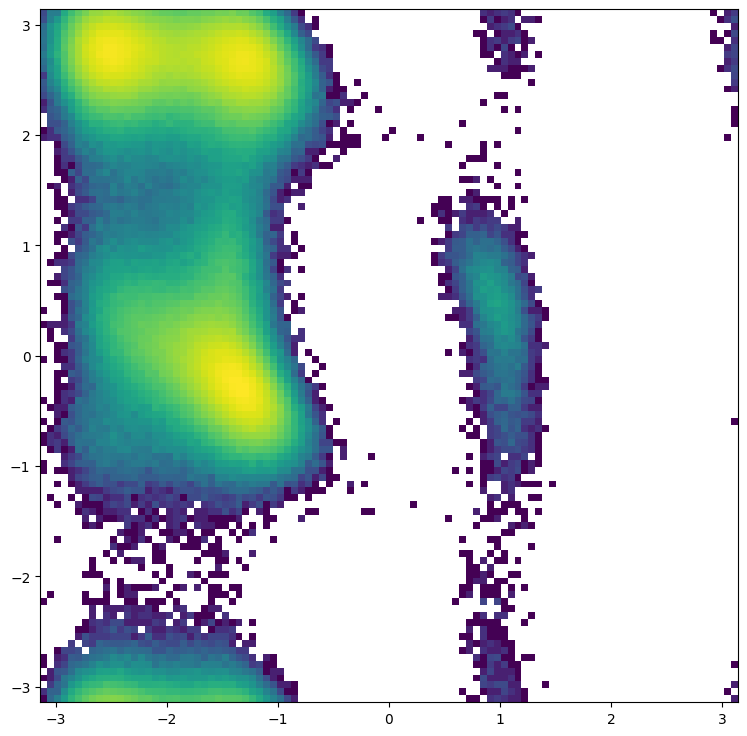

Process Worker-5:
Process Worker-13:
Process Worker-39:
Process Worker-34:
Process Worker-20:
Process Worker-23:
Process Worker-52:
Process Worker-2:
Process Worker-59:
Process Worker-35:
Process Worker-36:
Process Worker-56:
Process Worker-25:
Process Worker-19:
Process Worker-24:
Process Worker-54:
Process Worker-44:
Process Worker-27:
Process Worker-9:
Process Worker-10:
Process Worker-53:
Process Worker-7:
Process Worker-4:
Process Worker-32:
Process Worker-3:
Process Worker-33:
Process Worker-21:
Process Worker-37:
Process Worker-60:
Process Worker-31:
Process Worker-8:
Process Worker-18:
Process Worker-14:
Process Worker-48:
Process Worker-16:
Process Worker-15:
Process Worker-12:
Process Worker-17:
Process Worker-22:
Process Worker-41:
Process Worker-42:
Process Worker-46:
Process Worker-64:
Process Worker-45:
Process Worker-50:
Process Worker-62:
Process Worker-63:
Process Worker-57:
Process Worker-38:
Process Worker-43:
Process Worker-55:
Process Worker-47:
Process Worker-1:
P

In [1]:
import tqdm
import torch
import numpy as np
from bgflow.utils import as_numpy
from bgflow import DiffEqFlow, BoltzmannGenerator, MeanFreeNormalDistribution
from bgflow import BlackBoxDynamics, BruteForceEstimator
from tbg.models2 import EGNN_dynamics_AD2_cat

from bgmol.datasets import AImplicitUnconstrained
import mdtraj as md
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
dataset = AImplicitUnconstrained(read=True, download=False)
n_particles = 22
n_dimensions = 3
scaling = 10
dim = n_particles * n_dimensions
data = dataset.xyz
target = dataset.get_energy_model()
data_energies = target.energy(torch.from_numpy(dataset.xyz[::10].reshape(-1,66)))
ala_traj = md.Trajectory(dataset.xyz, dataset.system.mdtraj_topology)
phi = md.compute_phi(ala_traj)[1].flatten()
psi = md.compute_psi(ala_traj)[1].flatten()
plt.figure(figsize=(9,9))
plt.hist2d(phi, psi, bins=100, norm=LogNorm());

In [2]:
import math

n_particles = 22
n_dimensions = 3
dim = n_particles * n_dimensions

scaling = 10

# atom types for backbone
n_particles = 22
n_dimensions = 3
dim = n_particles * n_dimensions


# atom types for backbone
atom_types = np.array(
    [1, 0, 0, 0, 4, 3, 5, 0, 6, 0, 1, 0, 0, 0, 7, 3, 8, 0, 1, 0, 0, 0]
)
h_initial = torch.nn.functional.one_hot(torch.tensor(atom_types))


# now set up a prior
prior = MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()
prior_cpu = MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False)

brute_force_estimator = BruteForceEstimator()
net_dynamics = EGNN_dynamics_AD2_cat(
    n_particles=n_particles,
    device="cuda",
    n_dimension=dim // n_particles,
    h_initial=h_initial,
    hidden_nf=64,
    act_fn=torch.nn.SiLU(),
    n_layers=5,
    recurrent=True,
    tanh=True,
    attention=True,
    condition_time=True,
    mode="egnn_dynamics",
    agg="sum",
)

bb_dynamics = BlackBoxDynamics(
    dynamics_function=net_dynamics, divergence_estimator=brute_force_estimator
)

flow = DiffEqFlow(dynamics=bb_dynamics)

bg = BoltzmannGenerator(prior, flow, prior).cuda()


class BruteForceEstimatorFast(torch.nn.Module):
    """
    Exact bruteforce estimation of the divergence of a dynamics function.
    """

    def __init__(self):
        super().__init__()
        self.n = 0

    def forward(self, dynamics, t, xs):
        self.n += 1

        with torch.set_grad_enabled(True):
            xs.requires_grad_(True)
            x = [xs[:, [i]] for i in range(xs.size(1))]
            dxs = dynamics(t, torch.cat(x, dim=1))

            assert len(dxs.shape) == 2, "`dxs` must have shape [n_btach, system_dim]"
            divergence = 0
            for i in range(xs.size(1)):
                divergence += torch.autograd.grad(
                    dxs[:, [i]], x[i], torch.ones_like(dxs[:, [i]]), retain_graph=True
                )[0]

        return dxs, -divergence.view(-1, 1)

def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u, argnums=1)
    def f(t, x, *args): 
        x = x.unsqueeze(0)
        return torch.trace(J(t, x).squeeze())
    return f

class BruteForceEstimatorFaster(torch.nn.Module):
    
    def __init__(self):
        super().__init__()
        self.n = 0
        
    def forward(self, dynamics, t, xs):
        self.n += 1
        div = torch.vmap(exact_div_fn(dynamics), in_dims=(None, 0))(t, xs)
        dxs = dynamics(t, xs)
        return dxs, -div.view(-1, 1)

brute_force_estimator_fast = BruteForceEstimatorFaster()
# use OTD in the evaluation process
bb_dynamics._divergence_estimator = brute_force_estimator_fast
bg.flow._integrator_atol = 1e-1
bg.flow._integrator_rtol = 1e-1
flow._use_checkpoints = False
flow._kwargs = {}



In [3]:
x0_samples = prior.sample(10)

In [4]:
# brute_force_estimator_fast = BruteForceEstimatorFast()
# # use OTD in the evaluation process
# bb_dynamics._divergence_estimator = brute_force_estimator_fast
# filename = "Flow-Matching-AD2-amber-weighted-backbone"
# PATH_last = f"models/{filename}"
# checkpoint = torch.load(PATH_last)
# flow.load_state_dict(checkpoint["model_state_dict"])
# save_filename = "v2-Flow-Matching-AD2-amber-weighted-encoding"

# n_samples = 10
# n_sample_batches = 1
# latent_np = np.empty(shape=(0))
# samples_np = np.empty(shape=(0))
# dlogp_np = np.empty(shape=(0))
# print(f"Start sampling with {filename}")

# for i in tqdm.tqdm(range(n_sample_batches)):
#     with torch.no_grad():
#         samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True, sample=x0_samples)
#         print("n / i = ", brute_force_estimator_fast.n / (i+1))
#         latent_np = np.append(latent_np, latent.detach().cpu().numpy())
#         samples_np = np.append(samples_np, samples.detach().cpu().numpy())

#         dlogp_np = np.append(dlogp_np, as_numpy(dlogp))

#     latent_np = latent_np.reshape(-1, dim)
#     samples_np = samples_np.reshape(-1, dim)
#     np.savez(
#         f"../result_data/{save_filename}",
#         latent_np=latent_np,
#         samples_np=samples_np,
#         dlogp_np=dlogp_np,
#     )

In [5]:

# # use OTD in the evaluation process
# bb_dynamics._divergence_estimator = BruteForceEstimatorFaster()
# filename = "Flow-Matching-AD2-amber-weighted-backbone"
# PATH_last = f"models/{filename}"
# checkpoint = torch.load(PATH_last)
# flow.load_state_dict(checkpoint["model_state_dict"])
# save_filename = "v2-Flow-Matching-AD2-amber-weighted-encoding-faster"

# n_samples = 10
# n_sample_batches = 1
# latent_np = np.empty(shape=(0))
# samples_np = np.empty(shape=(0))
# dlogp_np = np.empty(shape=(0))
# print(f"Start sampling with {filename}")
# bb_dynamics._divergence_estimator.n = 0
# for i in tqdm.tqdm(range(n_sample_batches)):
#     with torch.no_grad():
#         samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True, sample=x0_samples)
#         print("n / i = ", bb_dynamics._divergence_estimator.n / (i+1))
#         latent_np = np.append(latent_np, latent.detach().cpu().numpy())
#         samples_np = np.append(samples_np, samples.detach().cpu().numpy())
#         dlogp_np = np.append(dlogp_np, as_numpy(dlogp))

#     latent_np = latent_np.reshape(-1, dim)
#     samples_np = samples_np.reshape(-1, dim)
#     np.savez(
#         f"../result_data/{save_filename}",
#         latent_np=latent_np,
#         samples_np=samples_np,
#         dlogp_np=dlogp_np,
#     )
# print(latent_np.shape, samples_np.shape, dlogp_np.shape)

In [7]:
def kish_effective_sample_size(weights: torch.Tensor) -> torch.Tensor:
    """
    Computes the Kish effective sample size (ESS) for a set of weights.
    
    Args:
        weights (torch.Tensor): A 1D tensor of sample weights.
        
    Returns:
        torch.Tensor: The effective sample size (scalar).
    """
    # Sum of weights
    sum_w = torch.sum(weights)
    # Sum of squared weights
    sum_w_sq = torch.sum(weights ** 2)
    # Kish formula for ESS
    ess = sum_w.pow(2) / sum_w_sq
    return ess

In [48]:
data[:10].shape

(10, 22, 3)

In [53]:
X_0 = prior.sample(n_samples)
target_energy(X_0)

tensor([[5539054.5000],
        [9018106.0000]], device='cuda:0')

In [55]:
prior.energy(X_0)

tensor([[25.8349],
        [34.0699]], device='cuda:0')

In [76]:
x = prior.sample(2)
x.requires_grad_(True)
e = target_energy(x)
torch.autograd.grad(e.sum(), x)

(tensor([[-1085780.5000,   181137.7031,   540344.4375,   183940.5156,
             76351.0078,   -39394.6953,    67557.9219,   301252.0938,
            -54853.4297,   103249.8750,    57119.5195,  -136748.8750,
           -717752.3750,   311013.0000,  -460689.5312,   310607.6562,
            120972.2734,   110297.7500,   535171.0625,  -433362.2188,
            512438.2188,  -135349.5156,    82447.2812,  -205161.8438,
           -106545.4219,    57178.3672,  -156993.4375,    89063.5938,
            -89782.6641,   -54949.5977,   630398.5625,  -267046.2188,
            130795.6328,   515535.5938,  -795907.0000,  -118876.5781,
           -175014.1250,   202313.6094,   -33633.9258,  -131281.3438,
            101831.1328,   -19610.8945,  -453417.3125,   188621.3281,
           -581543.6250,   313629.5625,  -218676.0156,   464658.4688,
            152388.8750,   401090.9688,   -90979.8203,    22497.5137,
           -127840.2266,   136138.9062,  -649808.9375,   -21021.6426,
            373448.3

In [50]:
target_energy(torch.from_numpy(data[:10].reshape(10, -1)).cuda())

tensor([[-21.4975],
        [-18.8361],
        [-23.4368],
        [-26.1344],
        [-30.0407],
        [-25.8484],
        [-21.3053],
        [-20.4789],
        [-29.6834],
        [-29.9853]], device='cuda:0')

In [93]:
from scipy.stats import qmc
eps = 0.001
num_timesteps = 10000

def prior_energy(x):
    x0, dlogp_rev = bg._flow(x, inverse=True)
    print("dlogp", dlogp_rev)
    return -(-prior.energy(x0) - dlogp_rev)

target_energy = lambda x: target.energy(x)

def linear_energy_interpolation(x, t):
    # print("shapes", x.shape, t.shape, prior_energy(x).shape, target_energy(x).shape)
    return target_energy(x)
    return ((1 - t) * prior_energy(x) + t * target_energy(x)).squeeze()

def energy_grad(x, t):
    with torch.enable_grad():
        x.requires_grad_(True)
        t.requires_grad_(True)
        t = t.repeat(x.shape[0], 1).to(x)
        et = linear_energy_interpolation(x, t)
        x_grad, t_grad = torch.autograd.grad(et.sum(), (x, t), allow_unused=True)
        if x_grad is None:
            #print("x_grad is none")
            x_grad = torch.zeros_like(x)
        t_grad = torch.zeros_like(t)
        return x_grad, t_grad.squeeze(1)
energy_partial_t_fn = torch.vmap(torch.func.grad(linear_energy_interpolation, argnums=1), in_dims=(0, None))
n_samples=2
n_sample_batches=1
X_0 = prior.sample(n_samples)
X = X_0.clone()
#initial_prior = prior_energy(X)
A = torch.zeros(X.shape[0]).cuda() #
timesteps = torch.linspace(0, 1, num_timesteps + 1)
dt = 1 / num_timesteps
A_list = [A]
ESS_list = []
#sampler = qmc.Halton(d=1, scramble=True)
for i in range(n_sample_batches):
    with torch.no_grad():
        for j, t in tqdm.tqdm(enumerate(timesteps[:-1])):
            energy_grad_x, energy_grad_t = energy_grad(X, t)
            dX_t = - eps * energy_grad_x * dt + math.sqrt(2 * eps * dt) * torch.randn_like(X)
            dA_t = - energy_grad_t * dt
            #print(dX_t.shape, dA_t.shape, X.shape, A.shape)
            #print(X[0][0])
            #print(energy_grad_x[0][0])
        
            # print("target energy", target_energy(X))
            X = X + dX_t
            A = A + dA_t
            A_list.append(A)
            ESS = kish_effective_sample_size(torch.softmax(A, dim=-1)).item() / len(A)
            ESS_list.append(ESS)
            
            if ESS < -1:
                #qmc_rand = sampler.random(n=len(A))
                #cum_prob = torch.cumsum(torch.softmax(A, dim=-1), dim=0)
                #indexes = np.searchsorted(cum_prob, qmc_rand, side="left").flatten()
                indexes = torch.multinomial(torch.softmax(A, dim=-1), len(A), replacement=True)
                X = X[indexes]
                A = torch.zeros_like(A)
            if j % 1000 == 0:
                print("energy", j, target_energy(X))
    
        jarzynski_samples = X
        jarzynski_weights = torch.softmax(A, dim=-1)

16it [00:01, 17.71it/s]

energy 0 tensor([[7511000.0000],
        [5359474.5000]], device='cuda:0')


1036it [00:06, 196.11it/s]

energy 1000 tensor([[ 568.1077],
        [1235.2107]], device='cuda:0')


2026it [00:11, 184.50it/s]

...

8026it [00:45, 177.57it/s]

energy 8000 tensor([[1.1158],
        [3.1564]], device='cuda:0')


9032it [00:51, 169.83it/s]

energy 9000 tensor([[ 1.5792],
        [-0.9733]], device='cuda:0')


10000it [00:56, 177.36it/s]


In [42]:
target_energy(X)

tensor([[inf],
        [inf]], device='cuda:0', grad_fn=<DivBackward0>)

In [41]:
target_energy(X_0)

tensor([[ 5668922.],
        [10506568.]], device='cuda:0')

torch.Size([])

In [22]:
energy_grad_t.shape

torch.Size([])

In [ ]:
classical_model_energies = as_numpy(target.energy(samples.reshape(-1, dim)))
classical_target_energies = as_numpy(target.energy(torch.from_numpy(data[::10]).reshape(-1, dim)))
prior = MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()
log_w_np = -classical_model_energies + as_numpy(prior.energy(torch.from_numpy(latent_np[idxs]).cuda())) + dlogp_np.reshape(-1,1)[idxs]


In [ ]:
dlogp_rev

In [ ]:
dlogp

In [ ]:
a = np.load("../result_data/Flow-Matching-AD2-amber-weighted-encoding.npz")

In [ ]:
ls models

In [ ]:
a["samples_np"]